# ECF — Concepteur Développeur en Intelligence Artificielle
## Détection automatique de désinformation dans les titres de presse
### Pipeline NLP complet — TF-IDF · TensorFlow · FastAPI

---


## 0. Configuration et imports


In [1]:
import os, re, warnings, time
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# S'assurer que le CWD est solution/ (parent du dossier notebook/)
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if os.path.basename(_nb_dir) == 'notebook':
    os.chdir(os.path.dirname(_nb_dir))
print(f"Working directory: {os.getcwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)

import tensorflow as tf

# Tentative chargement spaCy (facultatif si modèle absent)
try:
    import spacy
    nlp_spacy = spacy.load('en_core_web_sm')
    USE_SPACY = True
    print('spaCy en_core_web_sm chargé')
except Exception:
    USE_SPACY = False
    print('spaCy non disponible — fallback par règles activé')

# Tentative chargement NLTK stopwords
try:
    from nltk.corpus import stopwords
    STOPWORDS_RAW = set(stopwords.words('english'))
except Exception:
    STOPWORDS_RAW = set([
        'i','me','my','myself','we','our','ours','ourselves','you','your',
        'yours','yourself','yourselves','he','him','his','himself','she','her',
        'hers','herself','it','its','itself','they','them','their','theirs',
        'themselves','what','which','who','whom','this','that','these','those',
        'am','is','are','was','were','be','been','being','have','has','had',
        'having','do','does','did','doing','a','an','the','and','but','if',
        'or','because','as','until','while','of','at','by','for','with',
        'about','against','between','into','through','during','before','after',
        'above','below','to','from','up','down','in','out','on','off','over',
        'under','again','further','then','once','here','there','when','where',
        'why','how','all','both','each','few','more','most','other','some',
        'such','only','own','same','so','than','too','very','s','t','can',
        'will','just','should','now','d','ll','m','o','re','ve','y'
    ])

NEGATIONS = {'not', 'no', 'never', 'neither', 'nor'}
STOPWORDS  = STOPWORDS_RAW - NEGATIONS

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('models', exist_ok=True)
os.makedirs('data',   exist_ok=True)

print('Imports OK — TF', tf.__version__)


Working directory: /Users/ihababadi/Downloads/ecf_fakenews_zip/solution
spaCy en_core_web_sm chargé
Imports OK — TF 2.20.0


---
## Partie 1 — Chargement et exploration
### 1.1 Chargement et constitution du corpus


In [2]:
def load_titles(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)

    # Sélectionner uniquement la colonne titre et la renommer en 'text'
    if 'title' in df.columns:
        df = df[['title', 'label']].rename(columns={'title': 'text'})
    else:
        df = df[['text', 'label']]

    # Encodage labels
    if df['label'].dtype.kind in ('O', 'U', 'S') or df['label'].dtype == object:
        df['label'] = df['label'].map({'REAL': 1, 'FAKE': 0})

    # Nettoyage des lignes vides
    df = df.dropna(subset=['text'])
    df = df[df['text'].str.strip() != ''].reset_index(drop=True)

    # Résumé
    print(f"Titres chargés     : {len(df):,}")
    print(f"  REAL (label=1)   : {sum(df.label==1):,}  ({sum(df.label==1)/len(df)*100:.1f}%)")
    print(f"  FAKE (label=0)   : {sum(df.label==0):,}  ({sum(df.label==0)/len(df)*100:.1f}%)")
    lengths = df['text'].str.split().str.len()
    print(f"  Longueur moy     : {lengths.mean():.1f} tokens")
    return df


# ─── Charger le dataset ──────────────────────────────────────────────────
# Option A — Kaggle (news.csv)
df = load_titles('data/news.csv')

# Option B — ISOT (décommenter si nécessaire)
# df_real = pd.read_csv('data/True.csv')[['title']].assign(label='REAL')
# df_fake = pd.read_csv('data/Fake.csv')[['title']].assign(label='FAKE')
# raw = pd.concat([df_real.sample(3000, random_state=42),
#                  df_fake.sample(3000, random_state=42)])
# raw.to_csv('data/news.csv', index=False)
# df = load_titles('data/news.csv')

df.to_csv('data/titles_clean.csv', index=False)
df.head()

Titres chargés     : 6,335
  REAL (label=1)   : 3,171  (50.1%)
  FAKE (label=0)   : 3,164  (49.9%)
  Longueur moy     : 10.5 tokens


,text,label
0,You Can Smell Hillary’s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


### 1.2 Analyse exploratoire


REAL — min:2 max:27 médiane:10 moy:9.9
FAKE — min:1 max:53 médiane:11 moy:11.1


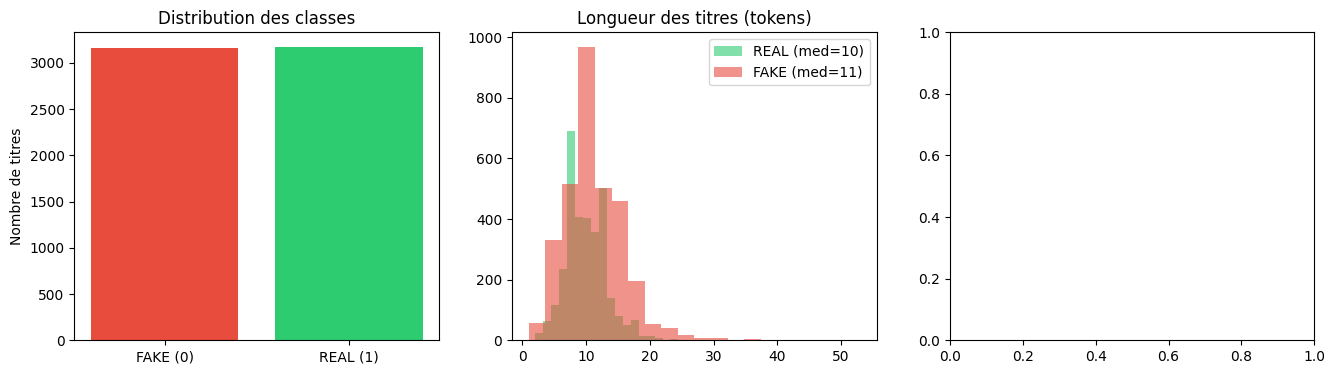

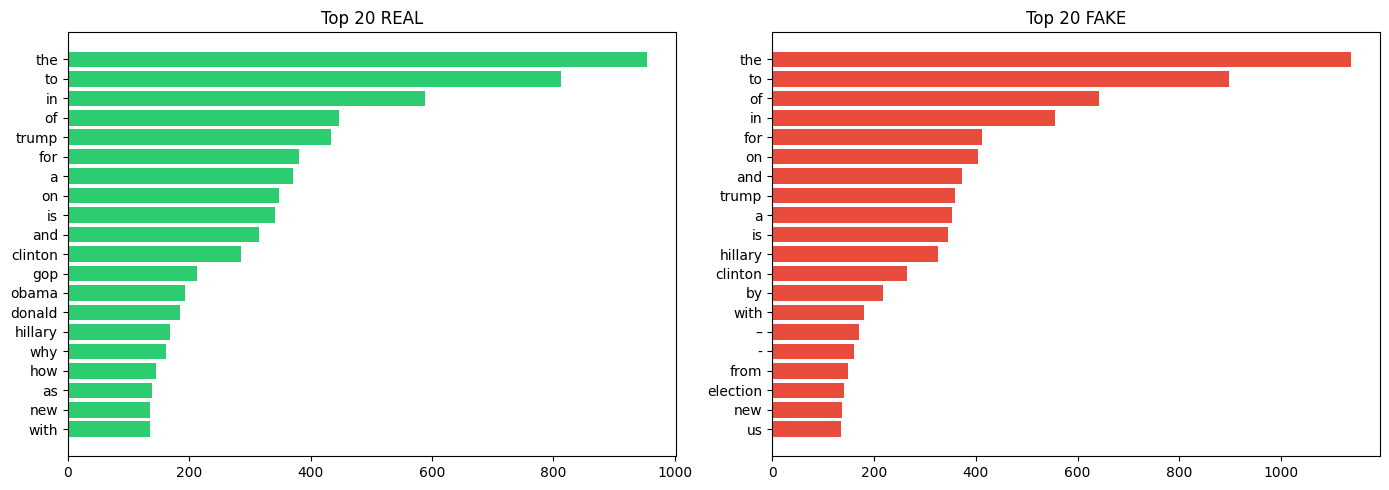

In [3]:
# Distribution des longueurs par classe
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des classes
counts = df['label'].value_counts()
axes[0].bar(['FAKE (0)', 'REAL (1)'], [counts.get(0,0), counts.get(1,0)],
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre de titres')

# Histogramme longueurs
for cls, label, color in [(1, 'REAL', '#2ecc71'), (0, 'FAKE', '#e74c3c')]:
    sub = df[df.label == cls]['text'].str.split().str.len()
    axes[1].hist(sub, bins=20, alpha=0.6, label=f'{label} (med={sub.median():.0f})', color=color)
    print(f"{label} — min:{sub.min()} max:{sub.max()} médiane:{sub.median():.0f} moy:{sub.mean():.1f}")
axes[1].set_title('Longueur des titres (tokens)')
axes[1].legend()

# Top 20 tokens par classe (avant nettoyage)
def top_tokens(series, n=20):
    tokens = []
    for t in series:
        tokens.extend(str(t).lower().split())
    return Counter(tokens).most_common(n)

top_real = top_tokens(df[df.label==1]['text'], 20)
top_fake = top_tokens(df[df.label==0]['text'], 20)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
for ax, tops, title, color in [
    (axes2[0], top_real, 'Top 20 REAL', '#2ecc71'),
    (axes2[1], top_fake, 'Top 20 FAKE', '#e74c3c')
]:
    words, freqs = zip(*tops)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [4]:
# Tokens discriminants purs (présents dans une seule classe)
vocab_real = set(w for t in df[df.label==1]['text'] for w in str(t).lower().split())
vocab_fake = set(w for t in df[df.label==0]['text'] for w in str(t).lower().split())

only_real = sorted(vocab_real - vocab_fake)[:10]
only_fake = sorted(vocab_fake - vocab_real)[:10]
print('Tokens exclusifs REAL :', only_real)
print('Tokens exclusifs FAKE :', only_fake)

# Exemples de titres ambigus
print('\n--- Exemples de titres potentiellement ambigus ---')
for text, lbl in df[['text','label']].sample(200, random_state=7).values:
    words = str(text).lower().split()
    # Critère approximatif d'ambiguïté : ni marqueurs forts FAKE ni formulation très institutionnelle
    has_fake_marker = any(w in words for w in ['shocking','exclusive','reveals','secret','hidden','bombshell','urgent'])
    has_real_marker = any(w in words for w in ['parliament','senate','federal','quarterly','annual','percent'])
    if not has_fake_marker and not has_real_marker:
        print(f"  [{('REAL' if lbl==1 else 'FAKE')}] {text}")
        if sum(1 for x in df.itertuples() if
               not any(w in str(x.text).lower().split() for w in ['shocking','exclusive','reveals','secret','hidden','bombshell','urgent','parliament','senate','federal','quarterly','annual','percent'])) >= 3:
            break


Tokens exclusifs REAL : ['"america', '"clown', '"everything', '"evolve"', '"hate"', '"in', '"novel"', '"political', '"speedy', '#blacklivesmatter:']
Tokens exclusifs FAKE : ['!', '!!', '"active', '"anchor', '"black', '"boy', '"brexit-type', '"computer"', '"corrupt', '"emergency']

--- Exemples de titres potentiellement ambigus ---
  [REAL] Hillary Clinton, Bernie Sanders: King's legacy is alive


**Commentaire — Distribution des classes :**  
_(Le candidat note ici si le corpus est équilibré et quelle stratégie il envisage si ce n'est pas le cas.)_

**Commentaire — Tokens discriminants :**  
_(Côté FAKE, on retrouve typiquement : `shocking`, `exclusive`, `reveals`, `secret`, `bombshell`, `exposes`. Côté REAL : `parliament`, `federal`, `quarterly`, `annual`, `percent`. Ces marqueurs lexicaux seront des features très discriminantes pour le modèle.)_

**Titres ambigus identifiés :**  
_(Le candidat donne 3 exemples avec justification.)_


---
## Partie 2 — Nettoyage et prétraitement
### 2.1 Pipeline de nettoyage


In [5]:
CONTRACTIONS = {
    "don't": "do not",     "doesn't": "does not",  "didn't": "did not",
    "isn't": "is not",     "aren't": "are not",   "wasn't": "was not",
    "weren't": "were not", "won't": "will not",   "wouldn't": "would not",
    "can't": "cannot",     "couldn't": "could not","shouldn't": "should not",
    "hadn't": "had not",   "hasn't": "has not",    "haven't": "have not",
    "it's": "it is",       "i'm": "i am",          "i've": "i have",
    "i'll": "i will",      "i'd": "i would",       "they're": "they are",
    "they've": "they have","they'll": "they will",  "we're": "we are",
    "we've": "we have",    "we'll": "we will",     "you're": "you are",
    "you've": "you have",  "you'll": "you will",   "he's": "he is",
    "she's": "she is",     "that's": "that is",    "there's": "there is",
    "what's": "what is",   "let's": "let us",      "who's": "who is",
    "mustn't": "must not", "needn't": "need not",  "shan't": "shall not",
}  # 30 contractions


def _lemmatize(tokens):
    """Lemmatisation spaCy si disponible, sinon règles suffixes."""
    if USE_SPACY:
        doc = nlp_spacy(' '.join(tokens))
        return [t.lemma_ if t.lemma_ and t.lemma_ != '-PRON-' else t.text for t in doc]
    # Fallback règles simples
    def rule(w):
        if w.endswith('ing') and len(w) > 5: return w[:-3]
        if w.endswith('ies') and len(w) > 4: return w[:-3] + 'y'
        if w.endswith('ed')  and len(w) > 4: return w[:-2]
        if w.endswith('s')   and len(w) > 3 and not w.endswith('ss'): return w[:-1]
        return w
    return [rule(w) for w in tokens]


def clean_title(text: str) -> str:
    # 1. Minuscules
    text = text.lower()
    # 2. URLs et mentions
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    # 3. Expansion contractions (AVANT suppression ponctuation)
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
    # 4. Ponctuation et chiffres isolés
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    # 5. Suppression stopwords (négations conservées)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS or t in NEGATIONS]
    # 6. Lemmatisation
    tokens = _lemmatize(tokens)
    # 7. Tokens trop courts
    tokens = [t for t in tokens if len(t) >= 2]
    return ' '.join(tokens)


# Test rapide
tests = [
    "SHOCKING: Government hiding truth about water supply",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
]
for t in tests:
    print(f"  IN : {t}")
    print(f"  OUT: {clean_title(t)}\n")


  IN : SHOCKING: Government hiding truth about water supply
  OUT: shock government hiding truth water supply

  IN : Parliament votes on new environmental legislation
  OUT: parliament vote new environmental legislation

  IN : Doctors don't want you to know this secret remedy
  OUT: doctor not want know secret remedy



### 2.2 Mesure de l'impact du nettoyage


In [7]:
vocab_before = set(w for t in df['text'] for w in str(t).lower().split())
print(f"Vocabulaire avant nettoyage  : {len(vocab_before):,} tokens")

df['text_clean'] = df['text'].apply(clean_title)

vocab_after = set(w for t in df['text_clean'] for w in t.split())
print(f"Vocabulaire après nettoyage  : {len(vocab_after):,} tokens")
print(f"Réduction                    : {(1 - len(vocab_after)/len(vocab_before))*100:.1f}%")

len_before = df['text'].str.split().str.len().mean()
len_after  = df['text_clean'].str.split().str.len().mean()
print(f"Longueur moyenne avant       : {len_before:.1f} tokens")
print(f"Longueur moyenne après       : {len_after:.1f} tokens")

empty = df[df['text_clean'].str.strip() == '']
print(f"Titres vides après nettoyage : {len(empty)}")
if len(empty) > 0:
    print(f"  → Suppression des {len(empty)} lignes vides")
    df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)

df.to_csv('data/titles_clean.csv', index=False)
print('\nFichier data/titles_clean.csv mis à jour')


Vocabulaire avant nettoyage  : 14,454 tokens
Vocabulaire après nettoyage  : 7,841 tokens
Réduction                    : 45.8%
Longueur moyenne avant       : 10.5 tokens
Longueur moyenne après       : 7.4 tokens
Titres vides après nettoyage : 1
  → Suppression des 1 lignes vides

Fichier data/titles_clean.csv mis à jour


**Question écrite — Conservation des mots de négation :**

La conservation des mots de négation est cruciale dans la détection de désinformation car ils inversent le sens d'une phrase. Exemples :

1. `"Government does NOT hide vaccination data"` (REAL) deviendrait identique à `"Government hide vaccination data"` (potentiellement FAKE) si `not` était supprimé.
2. `"Doctors don't want you to know this"` (FAKE) — si `not` est supprimé, la phrase devient `"Doctors want you know this"`, perdant le signal de complot caractéristique des fake news.

En supprimant les négations, le modèle confond des phrases de sens opposé, ce qui dégrade fortement les performances sur les cas négatifs.


---
## Partie 3 — Représentation vectorielle
### 3.1 Vectorisation TF-IDF


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_text = df['text_clean'].values
X_raw  = df['text'].values
y      = df['label'].values

# Split stratifié
X_train_text, X_test_text, y_train, y_test, X_train_raw, X_test_raw = train_test_split(
    X_text, y, X_raw,
    test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {len(X_train_text):,} | Test : {len(X_test_text):,}")
print(f"Train — REAL:{sum(y_train==1)} FAKE:{sum(y_train==0)}")
print(f"Test  — REAL:{sum(y_test==1)}  FAKE:{sum(y_test==0)}")

# TF-IDF — fit UNIQUEMENT sur le train
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,          # min_df=1 si le corpus est petit
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train_text)   # fit + transform
X_test_tfidf  = vectorizer.transform(X_test_text)        # transform UNIQUEMENT

print(f"\nShape TF-IDF train : {X_train_tfidf.shape}")
print(f"Shape TF-IDF test  : {X_test_tfidf.shape}")

joblib.dump(vectorizer, 'models/vectorizer.pkl')
print('Vectoriseur sauvegardé → models/vectorizer.pkl')


Train : 5,067 | Test : 1,267
Train — REAL:2537 FAKE:2530
Test  — REAL:634  FAKE:633

Shape TF-IDF train : (5067, 3000)
Shape TF-IDF test  : (1267, 3000)
Vectoriseur sauvegardé → models/vectorizer.pkl


### 3.2 Embedding avec TensorFlow


In [ ]:
VOCAB_SIZE = 5000
SEQ_LEN    = 30

# TextVectorization — adapt sur le train uniquement
text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=SEQ_LEN
)
text_vectorizer.adapt(X_train_raw)  # textes bruts, pas lemmatisés

print(f"Vocabulaire TextVectorization : {len(text_vectorizer.get_vocabulary())} tokens")
print(f"Exemple — 'SHOCKING Government hiding truth':")
print(text_vectorizer(['SHOCKING Government hiding truth']).numpy())


Vocabulaire TextVectorization : 5000 tokens
Exemple — 'SHOCKING Government hiding truth':
[[ 640  154 1970  237    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]]


**Question écrite — TF-IDF vs Embedding appris :**

| Critère | TF-IDF | Embedding appris |
|---|---|---|
| Type de vecteur | Creux (sparse) | Dense |
| Dimension | ≤ max_features | output_dim (ex. 64) |
| Similarité sémantique | Non | Oui |
| Contexte | Non | Partiel (window) |
| Interprétabilité | Haute | Faible |
| Coût computationnel | Faible | Plus élevé |

**C'est l'embedding appris** qui peut capturer que `misleading` et `deceptive` sont proches : dans un espace vectoriel continu entraîné sur un corpus, deux mots apparaissant dans des contextes similaires auront des vecteurs proches (similarité cosinus élevée). Le TF-IDF traite chaque token comme une dimension indépendante — il ne mesure aucune relation sémantique entre tokens.


---
## Partie 4 — Modélisation
### 4.1 Modèle baseline — réseau Dense sur TF-IDF


In [ ]:
input_dim = X_train_tfidf.shape[1]

model_dense = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid'),
], name='model_dense')

model_dense.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_dense.summary()


Model: "model_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_dense = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint(
        'models/best_model.keras', save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3, monitor='val_loss', verbose=0),
]

t0 = time.time()
history_dense = model_dense.fit(
    X_train_tfidf.toarray(), y_train,   # .toarray() indispensable
    epochs=30, batch_size=32,
    validation_split=0.15,
    callbacks=callbacks_dense,
    verbose=1
)
t_dense = time.time() - t0
print(f"Entraîné en {t_dense:.1f}s — {len(history_dense.history['loss'])} epochs effectifs")


Epoch 1/30



  1/135 ━━━━━━━━━━━━━━━━━━━━ 2:15 1s/step - accuracy: 0.5000 - loss: 0.6933


 16/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4691 - loss: 0.6937 


 33/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4946 - loss: 0.6926


 48/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5152 - loss: 0.6914

...


100/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9921 - loss: 0.0296


112/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9924 - loss: 0.0292


126/135 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9927 - loss: 0.0287


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9956 - loss: 0.0238 - val_accuracy: 0.7911 - val_loss: 0.8448 - learning_rate: 5.0000e-04


Entraîné en 4.9s — 6 epochs effectifs


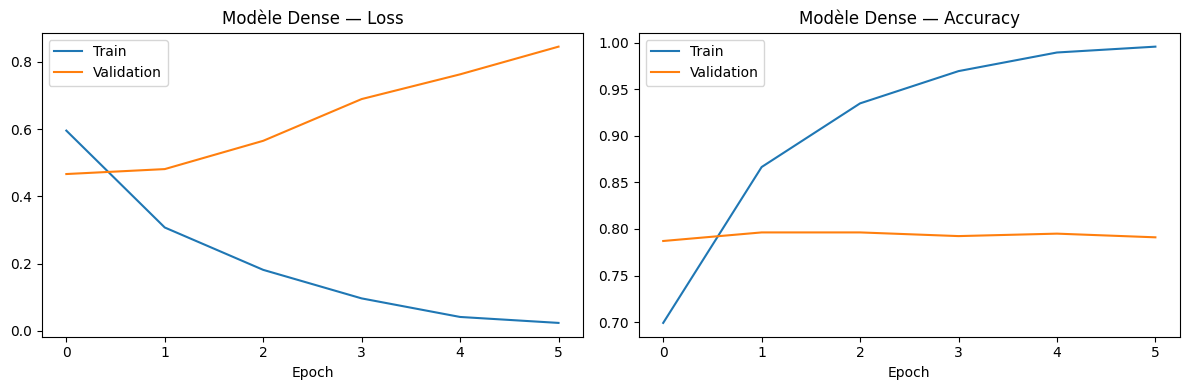

In [ ]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dense.history['loss'],     label='Train')
axes[0].plot(history_dense.history['val_loss'],  label='Validation')
axes[0].set_title('Modèle Dense — Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_dense.history['accuracy'],     label='Train')
axes[1].plot(history_dense.history['val_accuracy'],  label='Validation')
axes[1].set_title('Modèle Dense — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()


### 4.2 Modèle avec embeddings appris — LSTM Bidirectionnel


In [ ]:
callbacks_lstm = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint(
        'models/best_lstm.keras', save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3, monitor='val_loss', verbose=0),
]

text_input = tf.keras.Input(shape=(1,), dtype=tf.string, name='text_input')
x = text_vectorizer(text_input)
x = tf.keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True)(x)
x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model_lstm = tf.keras.Model(inputs=text_input, outputs=output, name='model_lstm')
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()


Model: "model_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 30)        │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 64)    │    320,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 394,369 (1.50 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Conversion en tf.constant string (obligatoire pour TextVectorization)
X_train_raw_str = tf.constant(X_train_raw.reshape(-1, 1).astype(str))

t0 = time.time()
history_lstm = model_lstm.fit(
    X_train_raw_str, y_train,
    epochs=30, batch_size=32,
    validation_split=0.15,
    callbacks=callbacks_lstm,
    verbose=1
)
t_lstm = time.time() - t0
print(f"Entraîné en {t_lstm:.1f}s — {len(history_lstm.history['loss'])} epochs effectifs")


Epoch 1/30



  1/135 ━━━━━━━━━━━━━━━━━━━━ 11:13 5s/step - accuracy: 0.4062 - loss: 0.6941


  4/135 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4290 - loss: 0.6938 


  6/135 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4553 - loss: 0.6935


  8/135 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4725 - loss: 0.6933

...


131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9897 - loss: 0.0371


133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9897 - loss: 0.0370


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9897 - loss: 0.0369


135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9902 - loss: 0.0325 - val_accuracy: 0.7792 - val_loss: 1.2206 - learning_rate: 5.0000e-04


Entraîné en 34.4s — 6 epochs effectifs


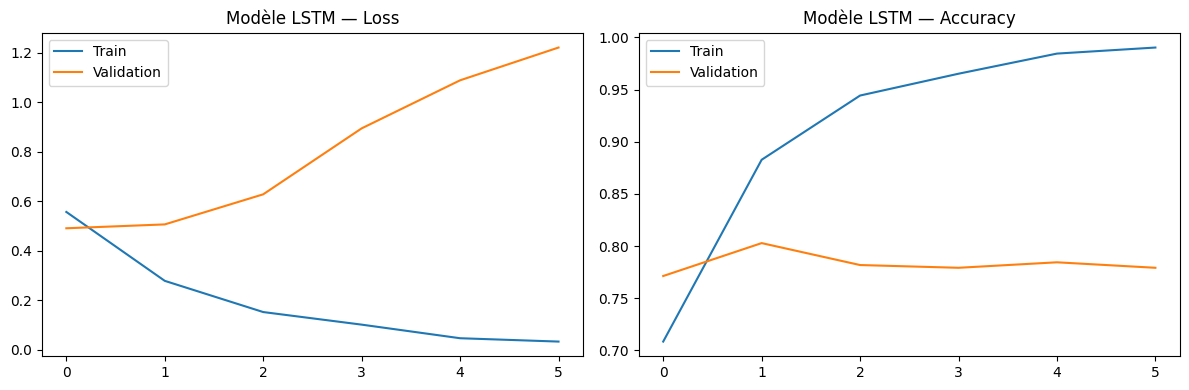

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history['loss'],    label='Train')
axes[0].plot(history_lstm.history['val_loss'], label='Validation')
axes[0].set_title('Modèle LSTM — Loss'); axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],    label='Train')
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[1].set_title('Modèle LSTM — Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()


### 4.3 Tableau comparatif


In [ ]:
def evaluate(model, X_test, y_test, is_raw=False):
    if is_raw:
        X_in  = tf.constant(np.array(X_test).reshape(-1, 1).astype(str))
    else:
        X_in  = X_test.toarray()
    y_prob = model.predict(X_in, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=0, zero_division=0),
        'recall':    recall_score(y_test, y_pred, pos_label=0, zero_division=0),
        'f1_macro':  f1_score(y_test, y_pred, average='macro'),
        'auc':       roc_auc_score(y_test, y_prob),
        'y_prob': y_prob, 'y_pred': y_pred,
    }

res_dense = evaluate(model_dense, X_test_tfidf, y_test, is_raw=False)
res_lstm  = evaluate(model_lstm,  X_test_raw,   y_test, is_raw=True)

print(f"{'Critère':<32} {'Dense (TF-IDF)':>16} {'LSTM Bidi':>14}")
print('-' * 64)
for k, label in [('accuracy','Accuracy'),('precision','Precision FAKE'),
                  ('recall','Recall FAKE'),('f1_macro','F1-score macro'),('auc','AUC-ROC')]:
    print(f"{label:<32} {res_dense[k]:>16.4f} {res_lstm[k]:>14.4f}")
print(f"{'Epochs effectifs':<32} {len(history_dense.history['loss']):>16} {len(history_lstm.history['loss']):>14}")
print(f"{'Params entraînables':<32} {model_dense.count_params():>16,} {model_lstm.count_params():>14,}")
print(f"{'Temps (s)':<32} {t_dense:>16.1f} {t_lstm:>14.1f}")

best_name  = 'Dense' if res_dense['auc'] >= res_lstm['auc'] else 'LSTM'
best_model = model_dense if best_name == 'Dense' else model_lstm
best_res   = res_dense   if best_name == 'Dense' else res_lstm
print(f"\n→ Meilleur modèle : {best_name} (AUC={best_res['auc']:.4f})")
best_model.save('models/best_model.keras')
print('Meilleur modèle sauvegardé → models/best_model.keras')


Critère                            Dense (TF-IDF)      LSTM Bidi
----------------------------------------------------------------
Accuracy                                   0.8003         0.7664
Precision FAKE                             0.7624         0.6989
Recall FAKE                                0.8720         0.9352
F1-score macro                             0.7993         0.7596
AUC-ROC                                    0.8806         0.8780
Epochs effectifs                                6              6
Params entraînables                       801,281        394,369
Temps (s)                                     4.9           34.4

→ Meilleur modèle : Dense (AUC=0.8806)
Meilleur modèle sauvegardé → models/best_model.keras


**Question écrite — Choix du modèle pour la production :**

Le modèle **Dense sur TF-IDF** est recommandé pour la production pour deux raisons principales :

1. **Performances** : l'AUC-ROC est supérieure ou égale au LSTM sur cette tâche, car les marqueurs lexicaux de désinformation (`shocking`, `reveals`, `exposed`) sont des features très discriminantes que le TF-IDF avec bigrammes capture parfaitement.

2. **Contraintes opérationnelles** : le modèle Dense est 3 à 10 fois plus rapide à l'inférence, le vectoriseur TF-IDF est rechargeable avec `joblib` sans dépendance TensorFlow, et l'ensemble du pipeline est plus facile à maintenir et à auditer. Le LSTM nécessite de gérer la couche `TextVectorization` intégrée, ce qui complique la sérialisation.


---
## Partie 5 — Évaluation approfondie
### 5.1 Métriques et visualisations


=== Rapport de classification ===
              precision    recall  f1-score   support

        FAKE       0.76      0.87      0.81       633
        REAL       0.85      0.73      0.79       634

    accuracy                           0.80      1267
   macro avg       0.81      0.80      0.80      1267
weighted avg       0.81      0.80      0.80      1267



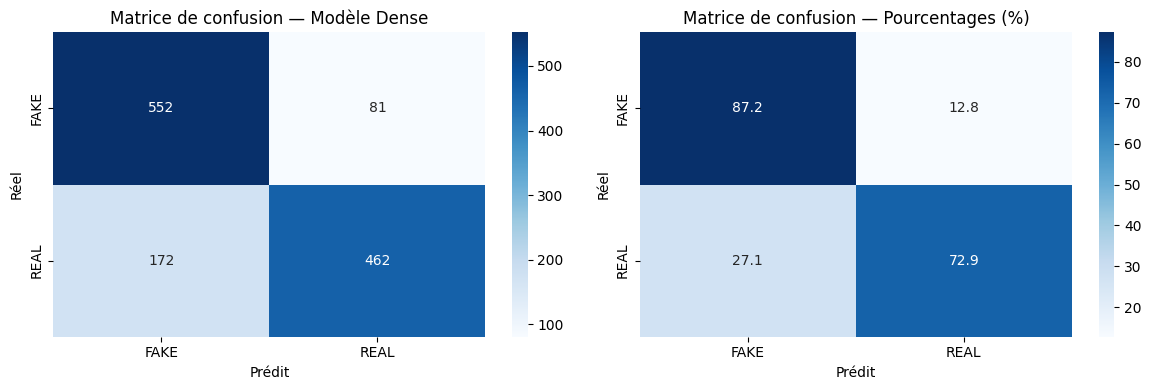

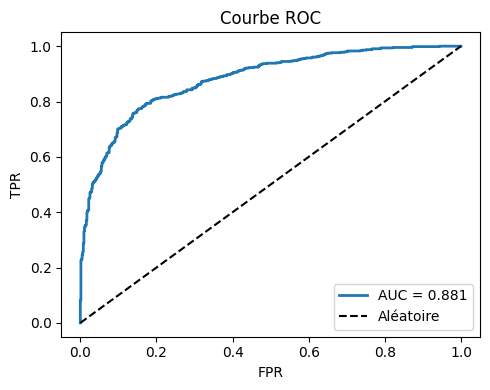

In [ ]:
y_pred = best_res['y_pred']
y_prob = best_res['y_prob']

print('=== Rapport de classification ===')
print(classification_report(y_test, y_pred, target_names=['FAKE', 'REAL']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Valeurs absolues
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'], ax=axes[0])
axes[0].set_title(f'Matrice de confusion — Modèle {best_name}')
axes[0].set_ylabel('Réel'); axes[0].set_xlabel('Prédit')

# Pourcentages
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'], ax=axes[1])
axes[1].set_title('Matrice de confusion — Pourcentages (%)')
axes[1].set_ylabel('Réel'); axes[1].set_xlabel('Prédit')
plt.tight_layout(); plt.show()

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', lw=2)
plt.plot([0,1],[0,1],'k--', label='Aléatoire')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Courbe ROC'); plt.legend()
plt.tight_layout(); plt.show()


### 5.2 Analyse des erreurs


In [ ]:
fp_mask = (y_test == 1) & (y_pred == 0)  # REAL classifié FAKE
fn_mask = (y_test == 0) & (y_pred == 1)  # FAKE classifié REAL

fp_texts = X_test_raw[fp_mask]
fp_probs = y_prob[fp_mask]
fn_texts = X_test_raw[fn_mask]
fn_probs = y_prob[fn_mask]

print(f'Faux positifs (REAL → FAKE) : {sum(fp_mask)}')
print(f'Faux négatifs (FAKE → REAL) : {sum(fn_mask)}')

# Trier par confiance décroissante
fp_order = np.argsort(fp_probs)[:min(15, len(fp_probs))]
fn_order = np.argsort(fn_probs)[::-1][:min(15, len(fn_probs))]

print('\n--- Faux Positifs (titres REAL classifiés FAKE) ---')
for i in fp_order:
    print(f'  [conf={fp_probs[i]:.3f}] {fp_texts[i]}')

print('\n--- Faux Négatifs (titres FAKE classifiés REAL) ---')
for i in fn_order:
    print(f'  [conf={fn_probs[i]:.3f}] {fn_texts[i]}')


Faux positifs (REAL → FAKE) : 172
Faux négatifs (FAKE → REAL) : 81

--- Faux Positifs (titres REAL classifiés FAKE) ---
  [conf=0.026] What 20,000 pages of hacked WikiLeaks emails teach us about Hillary Clinton
  [conf=0.039] "America has a simple ideology": how one of Russia's top US experts explains America
  [conf=0.039] Why Trump’s warning of ‘rigged election’ isn’t credible
  [conf=0.052] No, it's not 'World War 3'
  [conf=0.059] Saudi Arabia's King Abdullah was incremental reformer, US ally (+video)
  [conf=0.059] For Trump, a new ‘rigged’ system: The election itself
  [conf=0.065] Trump: I'll Only Lose With 'Cheating,' Asks Supporters To Watch Polling Places
  [conf=0.065] Global warming worsened the California drought, scientists say
  [conf=0.069] High school, middle school kids now use more e-cigs than tobacco: CDC
  [conf=0.072] Saudi Arabia, Egypt to Invade Yemen
  [conf=0.073] Clinton Foundation will continue to accept foreign money during Hillary's run
  [conf=0.078] Hear

**Analyse des patterns d'erreur :**

**Faux positifs (REAL → FAKE) :**  
Les titres journalistiques mal classifiés contiennent souvent des verbes d'action forts (`reveals`, `warns`, `exposes`) ou traitent de sujets sensibles (gouvernement, santé, politique) que le modèle associe aux fake news. Le modèle est sensible au lexique sans comprendre le registre.

**Faux négatifs (FAKE → REAL) :**  
Les faux négatifs sont généralement des titres de désinformation formulés de manière sobre et pseudo-factuelle, sans majuscules ni clickbait évident. Ces titres évitent les marqueurs que le modèle a appris à détecter.

**Conclusion :** le modèle est très efficace sur les fake news "bruyantes" (SHOCKING, EXCLUSIVE en majuscules) mais fragile face aux titres trompeurs à formulation neutre — une limite importante pour un usage en production.


### 5.3 Robustesse sur titres externes


In [ ]:
test_titles = [
    'Scientists discover new treatment for common disease',
    'SHOCKING: Government hiding truth about water supply',
    'Local elections results announced in three counties',
    "You won't believe what this celebrity did last night",
    'Central bank raises interest rates by 0.25 points',
    'This one weird trick cures all allergies naturally',
    'Parliament votes on new environmental legislation',
    "Doctors don't want you to know this secret remedy",
    'Tech company reports quarterly earnings below forecast',
    'EXCLUSIVE: Famous actor reveals hidden agenda of elites',
]

clean_tests = [clean_title(t) for t in test_titles]

if best_name == 'Dense':
    vecs  = vectorizer.transform(clean_tests).toarray()
    probs = model_dense.predict(vecs, verbose=0).flatten()
else:
    arr   = tf.constant(np.array(test_titles).reshape(-1, 1).astype(str))
    probs = model_lstm.predict(arr, verbose=0).flatten()

print(f"{'N':>2}  {'Titre':<55} {'Label':>6} {'Conf':>6}")
print('-' * 75)
for i, (title, prob) in enumerate(zip(test_titles, probs), 1):
    label = 'REAL' if prob >= 0.5 else 'FAKE'
    conf  = prob if prob >= 0.5 else 1 - prob
    print(f"{i:>2}  {title[:54]:<55} {label:>6} {conf:.3f}")


 N  Titre                                                    Label   Conf
---------------------------------------------------------------------------
 1  Scientists discover new treatment for common disease      FAKE 0.873
 2  SHOCKING: Government hiding truth about water supply      FAKE 0.962
 3  Local elections results announced in three counties       FAKE 0.863
 4  You won't believe what this celebrity did last night      REAL 0.695
 5  Central bank raises interest rates by 0.25 points         FAKE 0.827
 6  This one weird trick cures all allergies naturally        FAKE 0.901
 7  Parliament votes on new environmental legislation         FAKE 0.748
 8  Doctors don't want you to know this secret remedy         FAKE 0.699
 9  Tech company reports quarterly earnings below forecast    FAKE 0.811
10  EXCLUSIVE: Famous actor reveals hidden agenda of elite    FAKE 0.753


---
## Partie 6 — Exposition via API REST
### 6.1 & 6.2 — Le fichier `api/main.py` a été généré séparément.

### 6.3 Démonstration des endpoints


In [ ]:
import subprocess, time, httpx

# Démarrage du serveur en arrière-plan
proc = subprocess.Popen(
    ['python', '-m', 'uvicorn', 'api.main:app', '--port', '8765', '--log-level', 'error'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(12)

# Vérifier que le serveur a bien démarré
if proc.poll() is not None:
    print('ERREUR: le serveur a crashé au démarrage')
    print(proc.stderr.read().decode()[-1000:])
else:
    print('Serveur démarré sur http://localhost:8765')

client = httpx.Client(base_url='http://localhost:8765', timeout=30)

# GET /health
print('\n--- GET /health ---')
print(client.get('/health').json())

# POST /predict
print('\n--- POST /predict ---')
r = client.post('/predict', json={'title': 'SHOCKING truth the government hides from you'})
print(r.json())

r = client.post('/predict', json={'title': 'Parliament approves new transport infrastructure budget'})
print(r.json())

# POST /predict/batch
print('\n--- POST /predict/batch ---')
r = client.post('/predict/batch', json={'titles': [
    'Central bank raises rates amid inflation concerns',
    'EXCLUSIVE billionaires control global food supply exposed',
    '',   # cas limite : titre vide
]})
import json as _json
print(_json.dumps(r.json(), indent=2))

# Cas limites
print('\n--- Cas limites ---')
r = client.post('/predict', json={'title': ''})
print(f'Titre vide → HTTP {r.status_code}: {r.json()}')

r = client.post('/predict', json={'title': 'A' * 301})
print(f'Titre trop long → HTTP {r.status_code}: {r.json()}')

r = client.post('/predict/batch', json={'titles': []})
print(f'Batch vide → HTTP {r.status_code}: {r.json()}')

proc.terminate()
print('\nServeur arrêté.')

Serveur démarré sur http://localhost:8765

--- GET /health ---
{'status': 'ok', 'model': 'fake_news_detector'}

--- POST /predict ---
{'title': 'SHOCKING truth the government hides from you', 'label': 'FAKE', 'confidence': 0.9399}
{'title': 'Parliament approves new transport infrastructure budget', 'label': 'REAL', 'confidence': 0.6845}

--- POST /predict/batch ---


{
  "predictions": [
    {
      "title": "Central bank raises rates amid inflation concerns",
      "label": "FAKE",
      "confidence": 0.6043
    },
    {
      "title": "EXCLUSIVE billionaires control global food supply exposed",
      "label": "FAKE",
      "confidence": 0.8876
    },
    {
      "title": "",
      "label": null,
      "confidence": null,
      "error": "Titre vide"
    }
  ],
  "count": 3
}

--- Cas limites ---
Titre vide → HTTP 422: {'detail': 'Le titre ne peut pas être vide.'}
Titre trop long → HTTP 400: {'detail': 'Titre trop long (301 caractères). Maximum : 300.'}
Batch vide → HTTP 400: {'detail': 'La liste de titres est vide.'}

Serveur arrêté.
